In [1]:
# =========================================================
# SECTION 1 — INSTALL LIBRARIES
# =========================================================

!pip install tensorflow scikit-learn matplotlib seaborn opencv-python kagglehub

In [2]:
# =========================================================
# SECTION 2 — DOWNLOAD DATASET
# =========================================================

import kagglehub
import os

path = kagglehub.dataset_download("emmarex/plantdisease")

print("Dataset path:", path)

for item in os.listdir(path):
    print(item)

Using Colab cache for faster access to the 'plantdisease' dataset.
Dataset path: /kaggle/input/plantdisease
PlantVillage
plantvillage


In [3]:
# =========================================================
# SECTION 3 — CREATE CUSTOM DATASET
# =========================================================

import os
import shutil
import glob

# DELETE OLD DATASET
if os.path.exists("/content/research_dataset"):
    shutil.rmtree("/content/research_dataset")

pv = os.path.join(path, "PlantVillage")

new_base = "/content/research_dataset"

classes = [
    "Healthy",
    "Bacterial_Spot",
    "Mosaic_Virus",
    "Yellow_Curl_Virus"
]

for c in classes:
    os.makedirs(os.path.join(new_base, c), exist_ok=True)

mapping = {
    "Healthy": "Tomato_healthy",
    "Bacterial_Spot": "Tomato_Bacterial_spot",
    "Mosaic_Virus": "Tomato__Tomato_mosaic_virus",
    "Yellow_Curl_Virus": "Tomato__Tomato_YellowLeaf__Curl_Virus"
}

for target, source in mapping.items():

    src_folder = os.path.join(pv, source)

    files = (
        glob.glob(src_folder + "/*.JPG")
        + glob.glob(src_folder + "/*.jpg")
    )

    for f in files:
        shutil.copy(
            f,
            os.path.join(
                new_base,
                target,
                os.path.basename(f)
            )
        )

print("Dataset ready:", os.listdir(new_base))

Dataset ready: ['Healthy', 'Mosaic_Virus', 'Bacterial_Spot', 'Yellow_Curl_Virus']


In [4]:
# =========================================================
# SECTION 4 — IMPORTS + DATASET LOADING
# =========================================================

import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

from tensorflow.keras import layers, models, Model
from tensorflow.keras.applications import MobileNetV3Small
from tensorflow.keras.preprocessing import image_dataset_from_directory

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

from sklearn.utils.class_weight import compute_class_weight

import seaborn as sns

# =========================================================
# CONFIG
# =========================================================

DATASET = "/content/research_dataset"

IMG_SIZE = (224,224)

BATCH = 32

EPOCHS = 30

# =========================================================
# DATASET
# =========================================================

train_ds = image_dataset_from_directory(
    DATASET,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH
)

val_ds = image_dataset_from_directory(
    DATASET,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH
)

class_names = train_ds.class_names

print("Classes:", class_names)

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)

val_ds = val_ds.prefetch(AUTOTUNE)

# =========================================================
# CLASS WEIGHTS
# =========================================================

y_train = np.concatenate(
    [y.numpy() for x, y in train_ds],
    axis=0
)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

# =========================================================
# DATA AUGMENTATION
# =========================================================

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2)
])

Found 7299 files belonging to 4 classes.
Using 5840 files for training.
Found 7299 files belonging to 4 classes.
Using 1459 files for validation.
Classes: ['Bacterial_Spot', 'Healthy', 'Mosaic_Virus', 'Yellow_Curl_Virus']
{0: np.float64(0.8444187391555813), 1: np.float64(1.168), 2: np.float64(4.724919093851133), 3: np.float64(0.5721003134796239)}


In [5]:
# =========================================================
# SECTION 5 — BASELINE MODEL
# =========================================================

base_model = MobileNetV3Small(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model = models.Sequential([

    data_augmentation,

    layers.Rescaling(1./255),

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(256, activation="relu"),

    layers.Dropout(0.4),

    layers.Dense(
        len(class_names),
        activation="softmax"
    )
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=12,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stop],
    class_weight=class_weights
)

model.save("/content/baseline_model.keras")

print("Baseline model saved.")

4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/30
183/183 ━━━━━━━━━━━━━━━━━━━━ 178s 911ms/step - accuracy: 0.4200 - loss: 1.2714 - val_accuracy: 0.2337 - val_loss: 1.3978
Epoch 2/30
183/183 ━━━━━━━━━━━━━━━━━━━━ 163s 891ms/step - accuracy: 0.5257 - loss: 1.0377 - val_accuracy: 0.2337 - val_loss: 1.4259
Epoch 3/30
183/183 ━━━━━━━━━━━━━━━━━━━━ 164s 895ms/step - accuracy: 0.5685 - loss: 0.9292 - val_accuracy: 0.2337 - val_loss: 1.4745
Epoch 4/30
183/183 ━━━━━━━━━━━━━━━━━━━━ 169s 921ms/step - accuracy: 0.6111 - loss: 0.8493 - val_accuracy: 0.2337 - val_loss: 1.5888
Epoch 5/30
183/183 ━━━━━━━━━━━━━━━━━━━━ 167s 912ms/step - accuracy: 0.6512 - loss: 0.7524 - val_accuracy: 0.2337 - val_loss: 1.6874
Epoch 6/30
183/183 ━━━━━━━━━━━━━━━━━━━━ 164s 894ms/step - accuracy: 0.6779 - loss: 0.6993 - val_accuracy: 0.2337 - val_loss: 1.7189
Epoch 7/30
183/183 ━━━━━━━━━━━━━━━━━━━━ 207s 921ms/step - accuracy: 0.7142 - loss: 0.6390 - val_accuracy: 0.2337 - val_loss: 1.6318
Epoch 8/30
183/183 ━━━━━━━━

46/46 ━━━━━━━━━━━━━━━━━━━━ 20s 404ms/step
                   precision    recall  f1-score   support

   Bacterial_Spot       0.28      0.25      0.26       398
          Healthy       0.23      0.23      0.23       341
     Mosaic_Virus       0.00      0.00      0.00        64
Yellow_Curl_Virus       0.47      0.54      0.50       656

         accuracy                           0.36      1459
        macro avg       0.24      0.25      0.25      1459
     weighted avg       0.34      0.36      0.35      1459



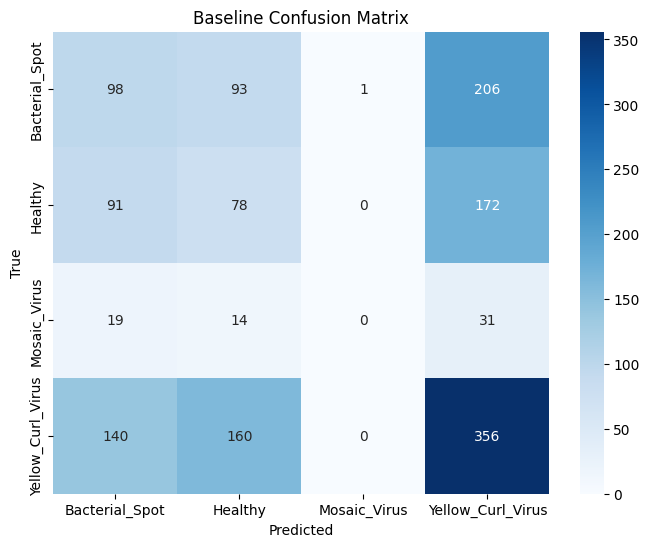

In [6]:
# =========================================================
# SECTION 6 — BASELINE METRICS
# =========================================================

y_true = np.concatenate(
    [y.numpy() for x, y in val_ds],
    axis=0
)

y_pred_probs = model.predict(val_ds)

y_pred = np.argmax(y_pred_probs, axis=1)

labels = list(range(len(class_names)))

print(classification_report(
    y_true,
    y_pred,
    labels=labels,
    target_names=class_names,
    zero_division=0
))

cm_base = confusion_matrix(
    y_true,
    y_pred,
    labels=labels
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm_base,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Baseline Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("True")

plt.show()

In [7]:
# =========================================================
# SECTION 7 — HECA-CBAM MODEL
# =========================================================

def cbam_block(x, ratio=8):

    ch = int(x.shape[-1])

    # Channel Attention
    avg = layers.GlobalAveragePooling2D()(x)

    maxp = layers.GlobalMaxPooling2D()(x)

    shared_dense1 = layers.Dense(
        ch // ratio,
        activation="relu"
    )

    shared_dense2 = layers.Dense(ch)

    avg = shared_dense2(shared_dense1(avg))

    maxp = shared_dense2(shared_dense1(maxp))

    ca = layers.Add()([avg, maxp])

    ca = layers.Activation("sigmoid")(ca)

    ca = layers.Reshape((1,1,ch))(ca)

    x = layers.Multiply()([x, ca])

    # Spatial Attention
    avg_pool = layers.Lambda(
        lambda z: tf.reduce_mean(
            z,
            axis=-1,
            keepdims=True
        )
    )(x)

    max_pool = layers.Lambda(
        lambda z: tf.reduce_max(
            z,
            axis=-1,
            keepdims=True
        )
    )(x)

    concat = layers.Concatenate(axis=-1)(
        [avg_pool, max_pool]
    )

    sa = layers.Conv2D(
        1,
        kernel_size=7,
        padding="same",
        activation="sigmoid"
    )(concat)

    x = layers.Multiply()([x, sa])

    return x


base = MobileNetV3Small(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)

base.trainable = True

for layer in base.layers[:-30]:
    layer.trainable = False

inputs = layers.Input(shape=(224,224,3))

x = data_augmentation(inputs)

x = layers.Rescaling(1./255)(x)

x = base(x, training=False)

x = cbam_block(x)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(256, activation="relu")(x)

x = layers.Dropout(0.4)(x)

outputs = layers.Dense(
    len(class_names),
    activation="softmax"
)(x)

heca_model = Model(inputs, outputs)

heca_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=12,
    restore_best_weights=True
)

history2 = heca_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stop],
    class_weight=class_weights
)

heca_model.save("/content/heca_model.keras")

print("HECA model saved.")

Epoch 1/30
183/183 ━━━━━━━━━━━━━━━━━━━━ 194s 993ms/step - accuracy: 0.4212 - loss: 1.2801 - val_accuracy: 0.0439 - val_loss: 1.4278
Epoch 2/30
183/183 ━━━━━━━━━━━━━━━━━━━━ 175s 956ms/step - accuracy: 0.5421 - loss: 1.0226 - val_accuracy: 0.2728 - val_loss: 1.4173
Epoch 3/30
183/183 ━━━━━━━━━━━━━━━━━━━━ 202s 954ms/step - accuracy: 0.5890 - loss: 0.8737 - val_accuracy: 0.2728 - val_loss: 1.3997
Epoch 4/30
183/183 ━━━━━━━━━━━━━━━━━━━━ 168s 920ms/step - accuracy: 0.6430 - loss: 0.7749 - val_accuracy: 0.2728 - val_loss: 1.3660
Epoch 5/30
183/183 ━━━━━━━━━━━━━━━━━━━━ 172s 938ms/step - accuracy: 0.6904 - loss: 0.6878 - val_accuracy: 0.2728 - val_loss: 1.3222
Epoch 6/30
183/183 ━━━━━━━━━━━━━━━━━━━━ 205s 959ms/step - accuracy: 0.7120 - loss: 0.6229 - val_accuracy: 0.2728 - val_loss: 1.2764
Epoch 7/30
183/183 ━━━━━━━━━━━━━━━━━━━━ 168s 914ms/step - accuracy: 0.7392 - loss: 0.5754 - val_accuracy: 0.2728 - val_loss: 1.2373
Epoch 8/30
183/183 ━━━━━━━━━━━━━━━━━━━━ 169s 924ms/step - accuracy: 0.7531 -

46/46 ━━━━━━━━━━━━━━━━━━━━ 20s 398ms/step
                   precision    recall  f1-score   support

   Bacterial_Spot       0.21      0.08      0.12       398
          Healthy       0.25      0.18      0.21       341
     Mosaic_Virus       0.00      0.00      0.00        64
Yellow_Curl_Virus       0.44      0.70      0.54       656

         accuracy                           0.38      1459
        macro avg       0.23      0.24      0.22      1459
     weighted avg       0.31      0.38      0.32      1459



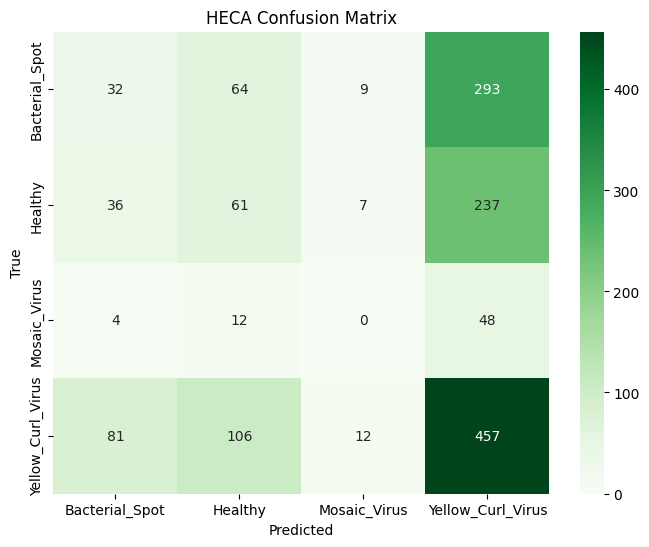

In [8]:
# =========================================================
# SECTION 8 — HECA METRICS
# =========================================================

y_true = np.concatenate(
    [y.numpy() for x, y in val_ds],
    axis=0
)

y_pred_probs = heca_model.predict(val_ds)

y_pred = np.argmax(y_pred_probs, axis=1)

labels = list(range(len(class_names)))

print(classification_report(
    y_true,
    y_pred,
    labels=labels,
    target_names=class_names,
    zero_division=0
))

cm_heca = confusion_matrix(
    y_true,
    y_pred,
    labels=labels
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm_heca,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("HECA Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("True")

plt.show()

In [ ]:
# =========================================================
# SECTION 9 — SE MODEL
# =========================================================

def se_block(x, ratio=8):

    ch = int(x.shape[-1])

    se = layers.GlobalAveragePooling2D()(x)

    se = layers.Dense(
        ch // ratio,
        activation="relu"
    )(se)

    se = layers.Dense(
        ch,
        activation="sigmoid"
    )(se)

    se = layers.Reshape((1,1,ch))(se)

    return layers.Multiply()([x, se])


base_se = MobileNetV3Small(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)

base_se.trainable = True

for layer in base_se.layers[:-30]:
    layer.trainable = False

inputs = layers.Input(shape=(224,224,3))

x = data_augmentation(inputs)

x = layers.Rescaling(1./255)(x)

x = base_se(x, training=False)

x = se_block(x)

x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(256, activation="relu")(x)

x = layers.Dropout(0.4)(x)

outputs = layers.Dense(
    len(class_names),
    activation="softmax"
)(x)

se_model = Model(inputs, outputs)

se_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=12,
    restore_best_weights=True
)

history3 = se_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stop],
    class_weight=class_weights
)

print("SE model saved.")

Epoch 1/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 114s 858ms/step - accuracy: 0.3772 - loss: 1.1790 - val_accuracy: 0.2269 - val_loss: 1.3777
Epoch 2/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 144s 876ms/step - accuracy: 0.5156 - loss: 1.0217 - val_accuracy: 0.2269 - val_loss: 1.3816
Epoch 3/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 140s 853ms/step - accuracy: 0.5472 - loss: 0.9501 - val_accuracy: 0.2269 - val_loss: 1.3834
Epoch 4/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 98s 863ms/step - accuracy: 0.5814 - loss: 0.8812 - val_accuracy: 0.2269 - val_loss: 1.3778
Epoch 5/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 98s 863ms/step - accuracy: 0.6089 - loss: 0.8243 - val_accuracy: 0.2269 - val_loss: 1.3594
Epoch 6/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 97s 856ms/step - accuracy: 0.6550 - loss: 0.7675 - val_accuracy: 0.2269 - val_loss: 1.3320
Epoch 7/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 142s 851ms/step - accuracy: 0.7028 - loss: 0.7070 - val_accuracy: 0.2269 - val_loss: 1.3039
Epoch 8/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 99s 877ms/step - accuracy: 0.7203 - los

29/29 ━━━━━━━━━━━━━━━━━━━━ 12s 398ms/step


/tmp/ipykernel_60922/2991579141.py:21: RuntimeWarning: invalid value encountered in divide
  cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)


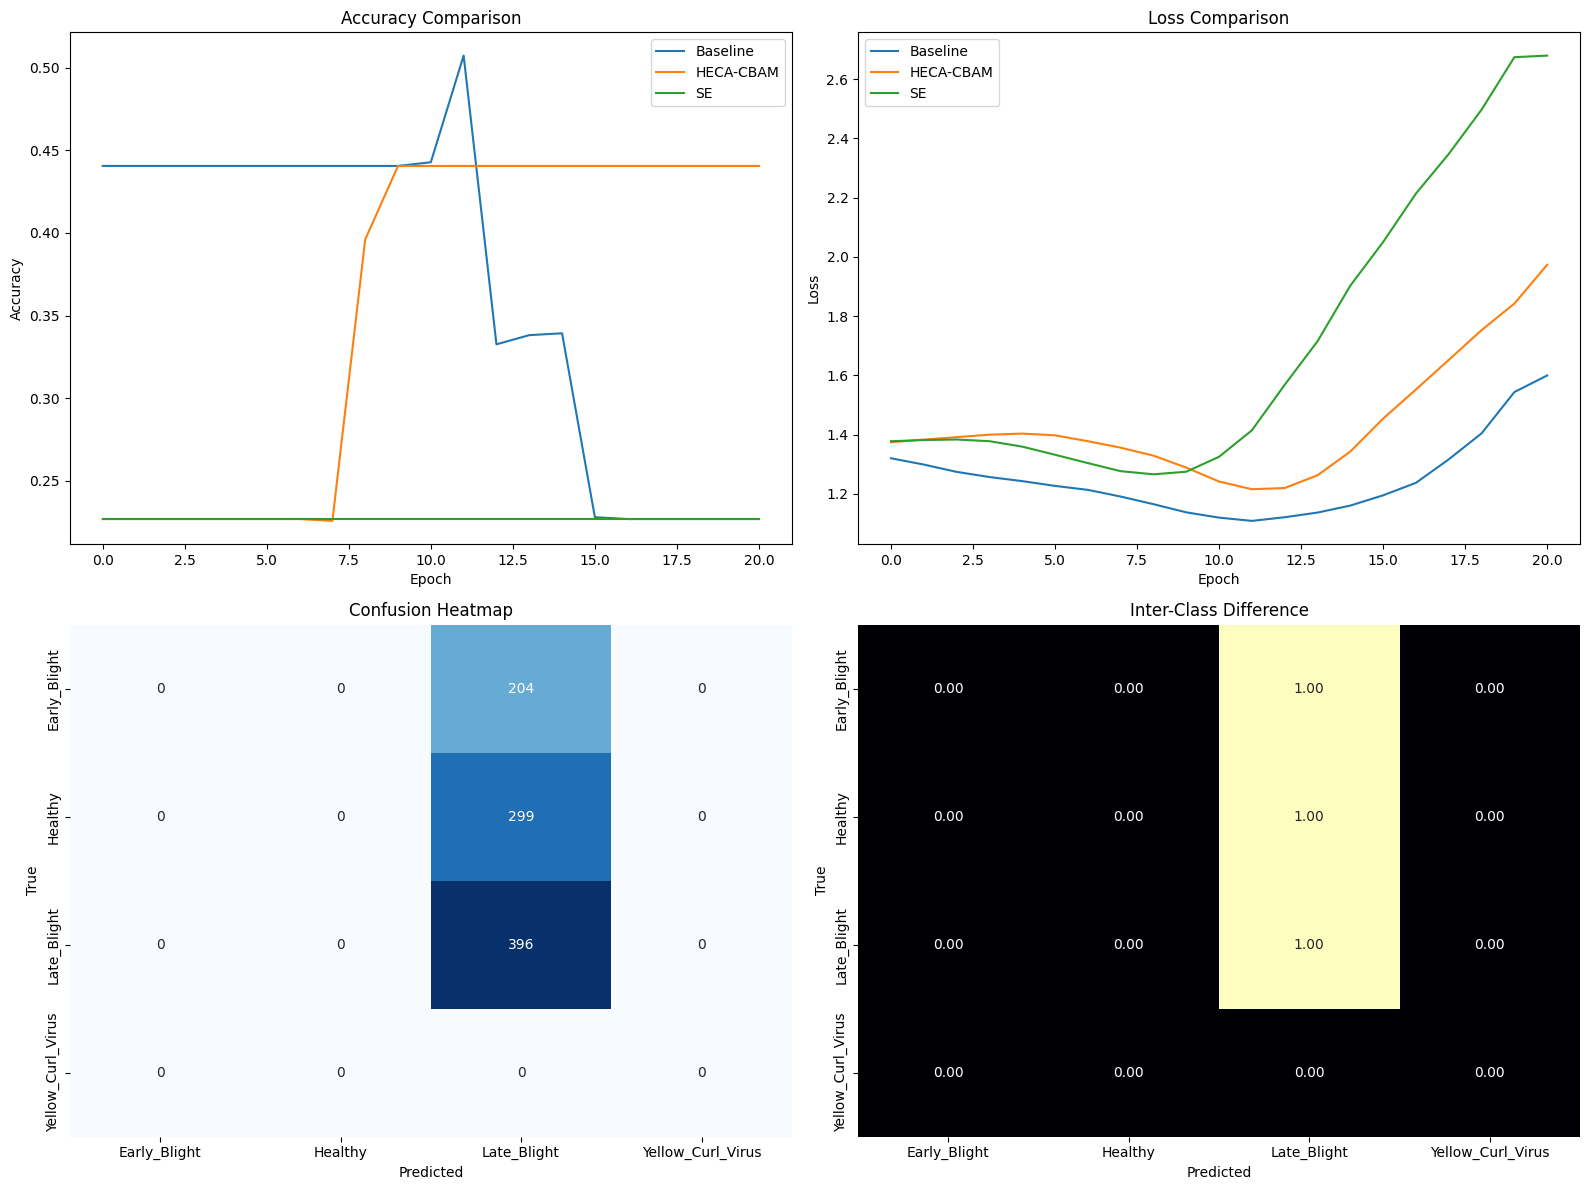

In [ ]:
# =========================================================
# SECTION 10 — FINAL COMPARISON
# =========================================================

y_true = np.concatenate(
    [y.numpy() for x, y in val_ds],
    axis=0
)

y_pred = np.argmax(
    heca_model.predict(val_ds),
    axis=1
)

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[0,1,2,3]
)

cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

cm_norm = np.nan_to_num(cm_norm)

min_epochs = min(
    len(history.history["val_accuracy"]),
    len(history2.history["val_accuracy"]),
    len(history3.history["val_accuracy"])
)

plt.figure(figsize=(16,12))

# =========================================================
# ACCURACY
# =========================================================
plt.subplot(2,2,1)

plt.plot(
    range(min_epochs),
    history.history["val_accuracy"][:min_epochs],
    label="Baseline"
)

plt.plot(
    range(min_epochs),
    history2.history["val_accuracy"][:min_epochs],
    label="HECA-CBAM"
)

plt.plot(
    range(min_epochs),
    history3.history["val_accuracy"][:min_epochs],
    label="SE"
)

plt.title("Accuracy Comparison")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

# =========================================================
# LOSS
# =========================================================
plt.subplot(2,2,2)

plt.plot(
    range(min_epochs),
    history.history["val_loss"][:min_epochs],
    label="Baseline"
)

plt.plot(
    range(min_epochs),
    history2.history["val_loss"][:min_epochs],
    label="HECA-CBAM"
)

plt.plot(
    range(min_epochs),
    history3.history["val_loss"][:min_epochs],
    label="SE"
)

plt.title("Loss Comparison")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

# =========================================================
# HEATMAP
# =========================================================
plt.subplot(2,2,3)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    cbar=False
)

plt.title("Confusion Heatmap")

plt.xlabel("Predicted")

plt.ylabel("True")

# =========================================================
# INTER-CLASS DIFFERENCE
# =========================================================
plt.subplot(2,2,4)

sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="magma",
    xticklabels=class_names,
    yticklabels=class_names,
    cbar=False
)

plt.title("Inter-Class Difference")

plt.xlabel("Predicted")

plt.ylabel("True")

plt.tight_layout()

plt.show()

46/46 ━━━━━━━━━━━━━━━━━━━━ 17s 369ms/step


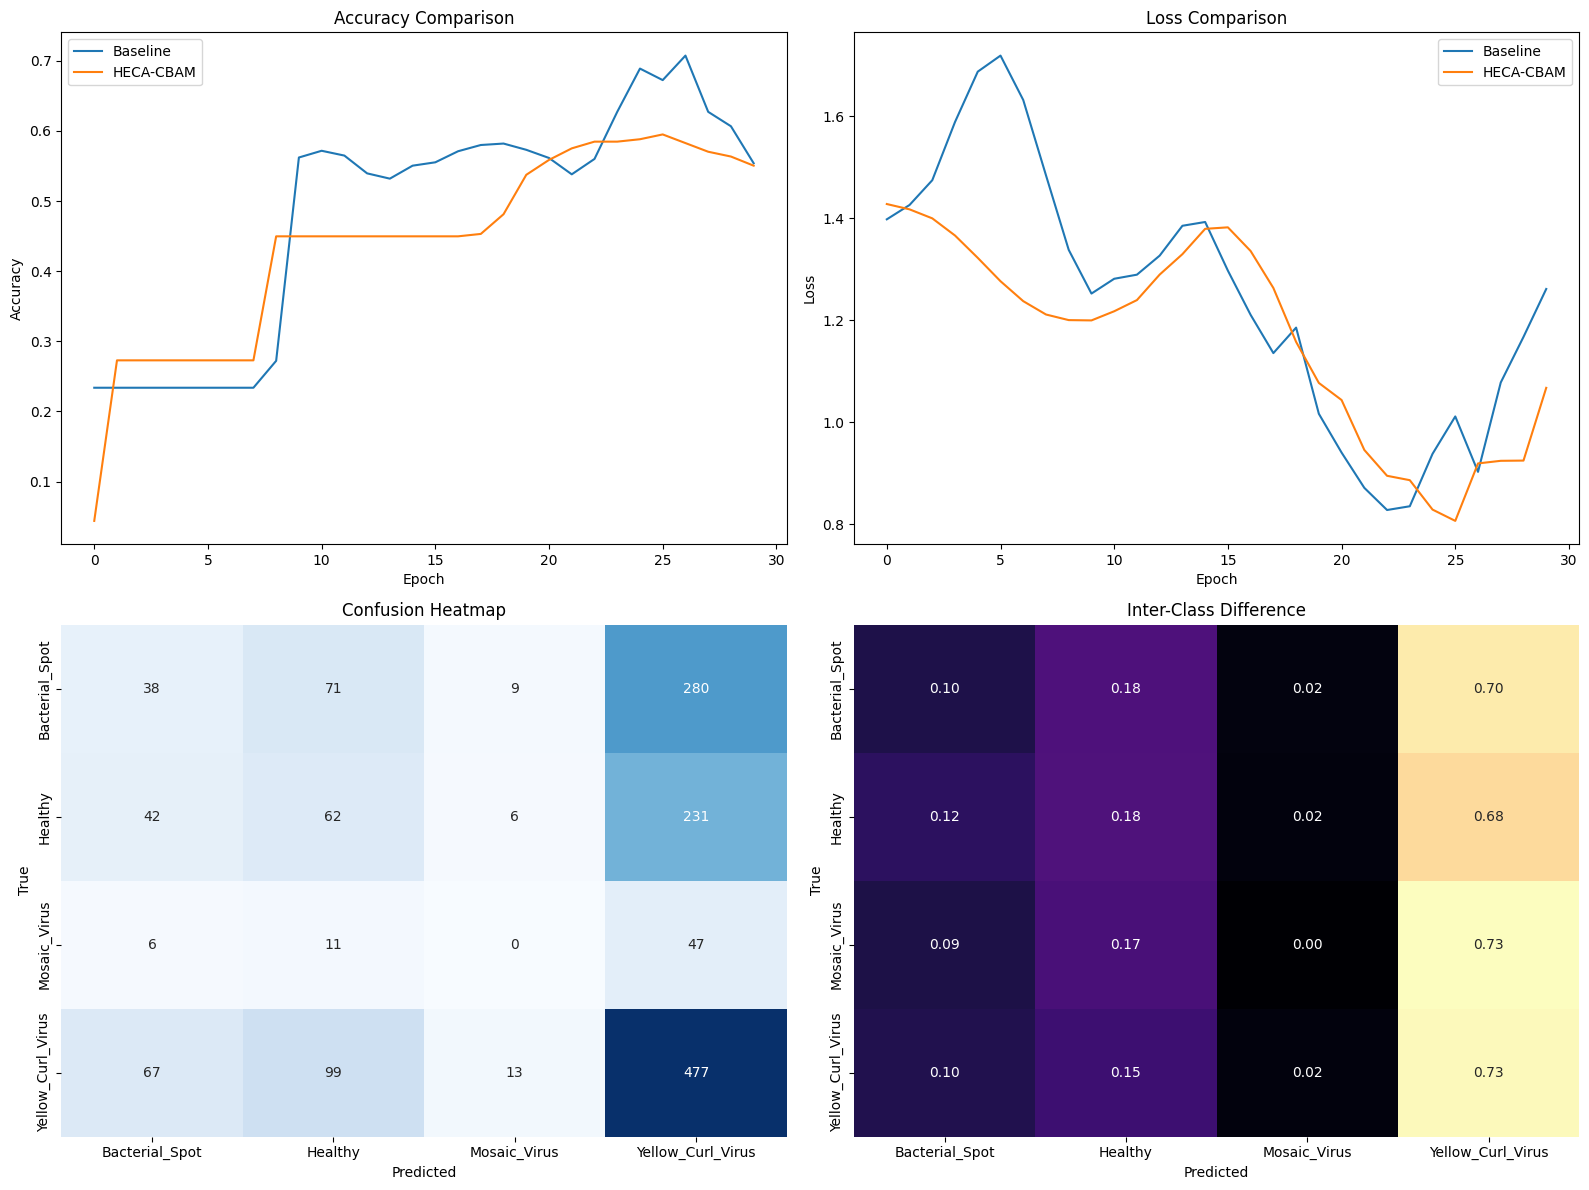

In [9]:
# =========================================================
# FINAL QUICK COMPARISON
# BASELINE vs HECA ONLY
# =========================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# =========================================================
# PREDICTIONS
# =========================================================
y_true = np.concatenate(
    [y.numpy() for x, y in val_ds],
    axis=0
)

y_pred = np.argmax(
    heca_model.predict(val_ds),
    axis=1
)

# =========================================================
# CONFUSION MATRIX
# =========================================================
cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[0,1,2,3]
)

# =========================================================
# NORMALIZED MATRIX
# =========================================================
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

cm_norm = np.nan_to_num(cm_norm)

# =========================================================
# COMMON EPOCH LENGTH
# =========================================================
min_epochs = min(
    len(history.history["val_accuracy"]),
    len(history2.history["val_accuracy"])
)

# =========================================================
# FIGURE
# =========================================================
plt.figure(figsize=(16,12))

# =========================================================
# 1 ACCURACY COMPARISON
# =========================================================
plt.subplot(2,2,1)

plt.plot(
    range(min_epochs),
    history.history["val_accuracy"][:min_epochs],
    label="Baseline"
)

plt.plot(
    range(min_epochs),
    history2.history["val_accuracy"][:min_epochs],
    label="HECA-CBAM"
)

plt.title("Accuracy Comparison")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

# =========================================================
# 2 LOSS COMPARISON
# =========================================================
plt.subplot(2,2,2)

plt.plot(
    range(min_epochs),
    history.history["val_loss"][:min_epochs],
    label="Baseline"
)

plt.plot(
    range(min_epochs),
    history2.history["val_loss"][:min_epochs],
    label="HECA-CBAM"
)

plt.title("Loss Comparison")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

# =========================================================
# 3 CONFUSION HEATMAP
# =========================================================
plt.subplot(2,2,3)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    cbar=False
)

plt.title("Confusion Heatmap")

plt.xlabel("Predicted")

plt.ylabel("True")

# =========================================================
# 4 INTER-CLASS DIFFERENCE
# =========================================================
plt.subplot(2,2,4)

sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="magma",
    xticklabels=class_names,
    yticklabels=class_names,
    cbar=False
)

plt.title("Inter-Class Difference")

plt.xlabel("Predicted")

plt.ylabel("True")

plt.tight_layout()

plt.show()